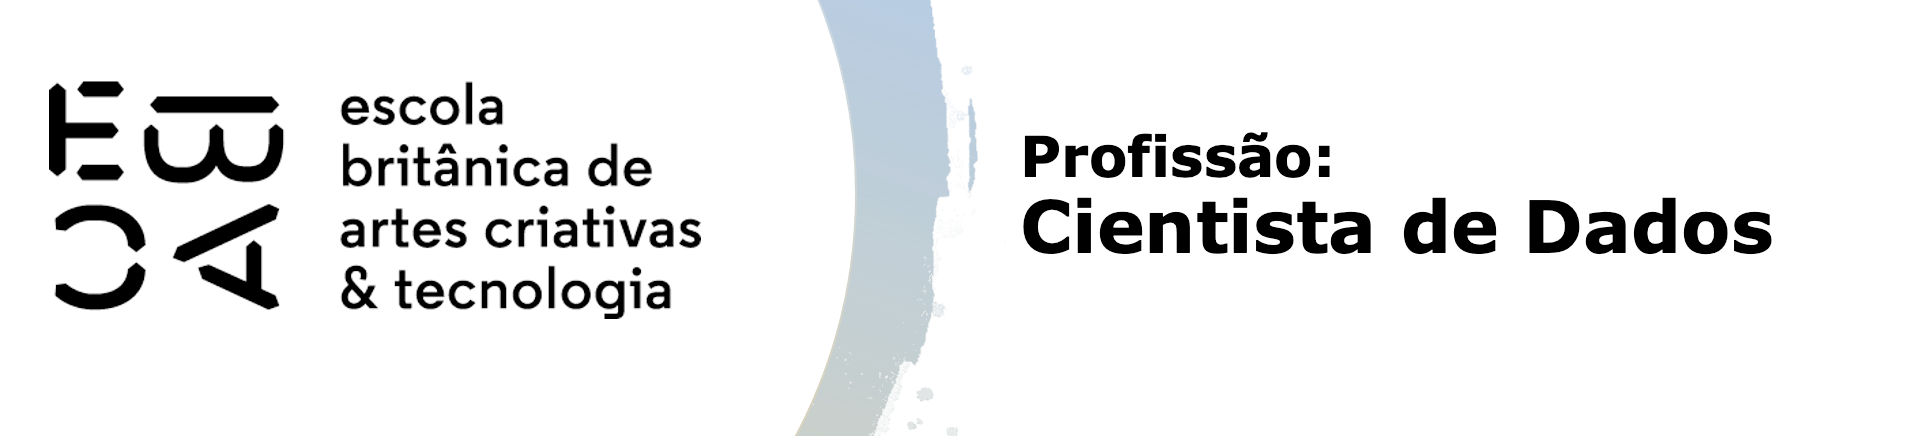

# Tarefa - Agrupamento hierárquico

Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?" 

Nosso objetivo agora é agrupar as sessões de acesso ao portal considerando o comportamento de acesso e informações da data, como a proximidade a uma data especial, fim de semana e o mês.

|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|Administrative          | Quantidade de acessos em páginas administrativas| 
|Administrative_Duration | Tempo de acesso em páginas administrativas | 
|Informational           | Quantidade de acessos em páginas informativas  | 
|Informational_Duration  | Tempo de acesso em páginas informativas  | 
|ProductRelated          | Quantidade de acessos em páginas de produtos | 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) | 
|Month                   | Mês  | 
|OperatingSystems        | Sistema operacional do visitante | 
|Browser                 | Browser do visitante | 
|Region                  | Região | 
|TrafficType             | Tipo de tráfego                  | 
|VisitorType             | Tipo de visitante: novo ou recorrente | 
|Weekend                 | Indica final de semana | 
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [1]:
# Importa as bibliotecas necessárias para análise de dados e visualização
import pandas as pd                # Manipulação de dados em DataFrames
import matplotlib.pyplot as plt    # Criação de gráficos
import seaborn as sns              # Visualização de dados estatísticos
import numpy as np                 # Operações numéricas e manipulação de arrays
import math

from sklearn.decomposition import PCA  # Análise de Componentes Principais (redução de dimensionalidade)
from sklearn.preprocessing import StandardScaler  # Padronização/normalização de dados
from sklearn.cluster import KMeans  # Algoritmo de agrupamento K-Means
from sklearn.metrics import silhouette_score # Avaliação da qualidade dos agrupamentos

# Importa função para buscar datasets do repositório UCI Machine Learning
from ucimlrepo import fetch_ucirepo

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram  # Métodos para agrupamento hierárquico
from gower import gower_matrix  # Cálculo de distância de Gower (para dados mistos)

from scipy.spatial.distance import pdist, squareform  # Funções para manipulação de matrizes de distância



In [2]:
# Busca o dataset "Online Shoppers Purchasing Intention" do repositório UCI
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468) 

# Extrai as features (variáveis explicativas) como um DataFrame do pandas
X = online_shoppers_purchasing_intention_dataset.data.features 

# Extrai o target (variável resposta) como um DataFrame do pandas
y = online_shoppers_purchasing_intention_dataset.data.targets 

In [3]:
# Concatena as variáveis explicativas (X) e a variável resposta (y) em um único DataFrame chamado df
df_original = pd.concat([X, y], axis=1)

# Exibe a contagem de valores únicos na coluna 'Revenue', incluindo valores ausentes (se houver)
df_original.Revenue.value_counts(dropna=False)

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [4]:
# Define a lista de variáveis que serão utilizadas na análise de agrupamento
variaveis_selecionadas = [
    "ProductRelated",              # Quantidade de acessos em páginas de produtos
    "ProductRelated_Duration",     # Tempo de acesso em páginas de produtos
    "BounceRates",                 # Percentual de visitantes que saem sem interagir
    "ExitRates",                   # Percentual de vezes que a página foi a última da sessão
    "PageValues",                  # Valor médio das páginas visitadas antes da compra
    "SpecialDay",                  # Proximidade de uma data especial
    "Month",                       # Mês da sessão
    "OperatingSystems",            # Sistema operacional do visitante
    "TrafficType",                 # Tipo de tráfego
    "VisitorType",                 # Tipo de visitante (novo ou recorrente)
    "Weekend",                     # Indica se a sessão ocorreu no fim de semana
    "Revenue",                     # Indica se houve compra na sessão
]

# Seleciona do DataFrame original apenas as colunas listadas em variaveis_selecionadas
df_variaveis_selecionadas = df_original[variaveis_selecionadas]

In [5]:
# Exibe as primeiras 5 linhas do DataFrame df_variaveis_selecionadas
# Isso permite visualizar rapidamente como estão os dados selecionados para análise
df_variaveis_selecionadas.head()

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,TrafficType,VisitorType,Weekend,Revenue
0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,Returning_Visitor,False,False
1,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,Returning_Visitor,False,False
2,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,3,Returning_Visitor,False,False
3,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,4,Returning_Visitor,False,False
4,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,4,Returning_Visitor,True,False


## Análise descritiva

Faça uma análise descritiva das variáveis do escopo.

- Verifique a distribuição dessas variáveis
- Veja se há valores *missing* e caso haja, decida o que fazer
- Faça mais algum tratamento nas variáveis caso ache pertinente

In [6]:
# Cria uma cópia do DataFrame df_variaveis_selecionadas para evitar alterações no original
df1 = df_variaveis_selecionadas.copy()

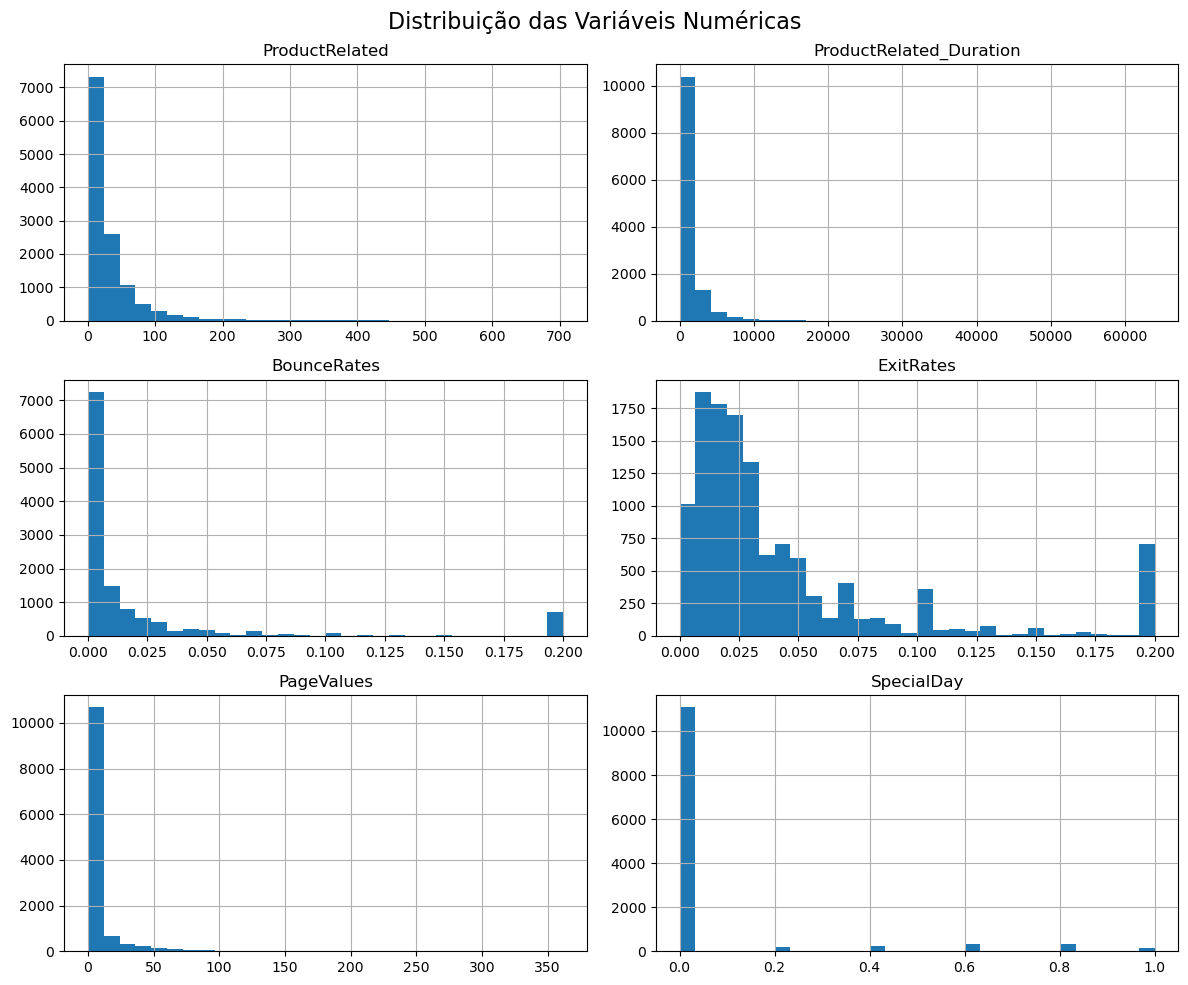

In [7]:
# Lista com os nomes das variáveis numéricas selecionadas para análise
variaveis_numericas = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

# Plota histogramas para cada variável numérica selecionada do DataFrame df1
df1[variaveis_numericas].hist(figsize=(12, 10), bins=30)
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=16)  # Título geral do conjunto de gráficos
plt.tight_layout()  # Ajusta o layout para evitar sobreposição dos gráficos
plt.show()  # Exibe os gráficos


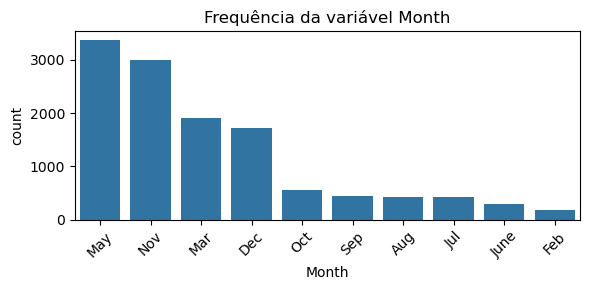

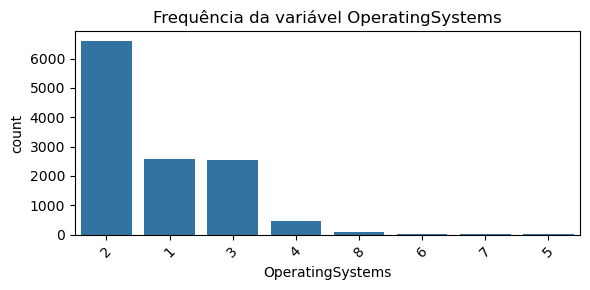

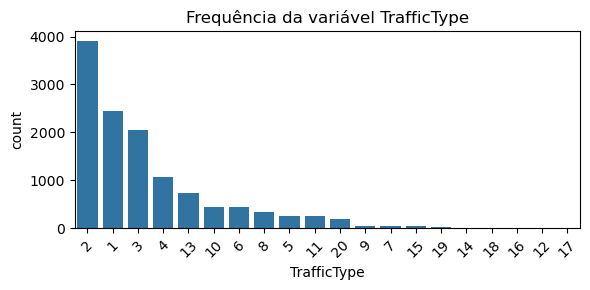

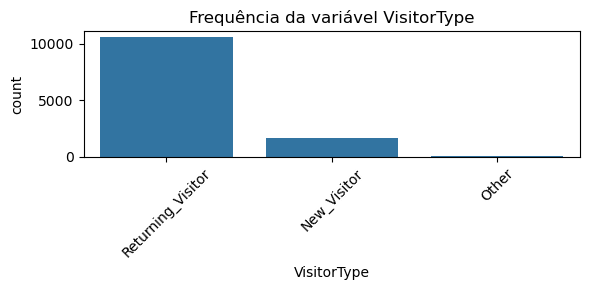

In [8]:
# Lista com os nomes das variáveis categóricas selecionadas para análise
variaveis_categoricas = ["Month", "OperatingSystems", "TrafficType", "VisitorType"]

# Para cada variável categórica, plota um gráfico de barras com a frequência de cada categoria
for var in variaveis_categoricas:
    plt.figure(figsize=(6, 3))  # Define o tamanho da figura
    sns.countplot(data=df1, x=var, order=df1[var].value_counts().index)  # Plota a contagem das categorias em ordem decrescente de frequência
    plt.title(f'Frequência da variável {var}')  # Adiciona um título ao gráfico
    plt.xticks(rotation=45)  # Rotaciona os rótulos do eixo x para melhor visualização
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição
    plt.show()  # Exibe o gráfico


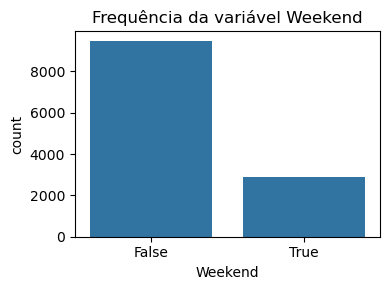

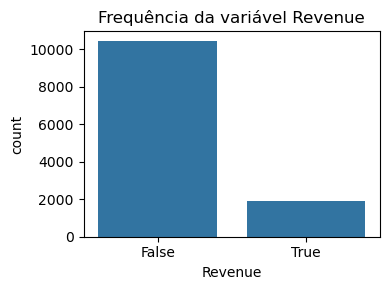

In [9]:
# Lista com os nomes das variáveis booleanas selecionadas para análise
variaveis_booleanas = ["Weekend", "Revenue"]

# Para cada variável booleana, plota um gráfico de barras com a frequência de cada categoria (True/False)
for var in variaveis_booleanas:
    plt.figure(figsize=(4, 3))  # Define o tamanho da figura
    sns.countplot(data=df1, x=var)  # Plota a contagem das categorias (True/False)
    plt.title(f'Frequência da variável {var}')  # Adiciona um título ao gráfico
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição
    plt.show()  # Exibe o gráfico


In [10]:
# Exibe os tipos de dados das colunas do DataFrame df_variaveis_selecionadas em formato de DataFrame (linha única)
df_variaveis_selecionadas.dtypes.to_frame().T

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,TrafficType,VisitorType,Weekend,Revenue
0,int64,float64,float64,float64,float64,float64,object,int64,int64,object,bool,bool


In [11]:
print('Há valores ausentes no dataframe ?\n','Existem valores nulos em df_variaveis_selecionadas' if df_variaveis_selecionadas.isna().sum().any() == True else 'Não')
# Verifica se existem valores nulos no DataFrame e exibe a soma de valores nulos por coluna

Há valores ausentes no dataframe ?
 Não


## Variáveis de agrupamento

Liste as variáveis que você vai querer utilizar. Essa é uma atividade importante do projeto, e tipicamente não a recebemos pronta. Não há resposta pronta ou correta, mas apenas critérios e a sua decisão. Os critérios são os seguintes:

- Selecione para o agrupamento variáveis que descrevam o padrão de navegação na sessão.
- Selecione variáveis que indiquem a característica da data.
- Não se esqueça de que você vai precisar realizar um tratamento especial para variáveis qualitativas.
- Trate adequadamente valores faltantes.

In [12]:
# Converte variáveis categóricas em variáveis dummies (variáveis indicadoras binárias)
# drop_first=True remove a primeira categoria de cada variável para evitar multicolinearidade
df1 = pd.get_dummies(df1, drop_first=True)

In [13]:
df1.columns

Index(['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates',
       'PageValues', 'SpecialDay', 'OperatingSystems', 'TrafficType',
       'Weekend', 'Revenue', 'Month_Dec', 'Month_Feb', 'Month_Jul',
       'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct',
       'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor'],
      dtype='object')

In [14]:
# Cria uma lista booleana indicando quais colunas de df1 são variáveis categóricas
# Para cada coluna em df1, se o nome da coluna NÃO está em variaveis_selecionadas, marca como True (categórica), senão False (não categórica)
vars_cat = [False if var in variaveis_selecionadas else True for var in df1.columns]

# Exibe a lista booleana resultante, que será usada para informar funções (como gower_matrix) sobre as variáveis categóricas
vars_cat

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True]

In [15]:
df1_std = StandardScaler().fit_transform(df1)  # Padroniza os dados para média 0 e desvio padrão 1
# Cria uma matriz de distância de Gower para os dados padronizados

In [16]:
distancia_gower = gower_matrix(df1_std, cat_features=vars_cat)
# Realiza o agrupamento hierárquico usando o método de ligação completa

In [17]:
# Exibe os 5 primeiros valores da matriz de distâncias de Gower
# Isso permite visualizar como ficaram as distâncias calculadas entre as primeiras observações do dataset
distancia_gower[:5, :5]

array([[0.        , 0.08085274, 0.02542069, 0.07119377, 0.1483897 ],
       [0.08085274, 0.        , 0.08765546, 0.03328948, 0.07706077],
       [0.02542069, 0.08765546, 0.        , 0.05937852, 0.13657445],
       [0.07119377, 0.03328948, 0.05937852, 0.        , 0.07719593],
       [0.1483897 , 0.07706077, 0.13657445, 0.07719593, 0.        ]],
      dtype=float32)

In [18]:
# Converte a matriz de distâncias de Gower (distancia_gower), que está no formato de matriz quadrada,
# para um vetor condensado (formato necessário para a função linkage do scipy).
# O parâmetro force='tovector' garante a conversão mesmo se a matriz já estiver no formato correto.
gdv = squareform(distancia_gower, force='tovector')

In [19]:
# Realiza o agrupamento hierárquico utilizando o método de ligação completa ('complete')
# Z é a matriz de ligação (linkage matrix) que armazena as informações das fusões dos clusters
Z = linkage(gdv, method='complete') 

# Converte a matriz de ligação em um DataFrame para facilitar a visualização e análise
# As colunas representam: Id1 (primeiro cluster unido), Id2 (segundo cluster unido), 
# Distancia (distância entre os clusters), Tamanho (número de elementos no novo cluster)
Z_df = pd.DataFrame(Z, columns=['Id1', 'Id2', 'Distancia', 'Tamanho'])

In [20]:
Z_df

,Id1,Id2,Distancia,Tamanho
0,16.0,85.0,0.000000,2.0
1,125.0,12330.0,0.000000,3.0
2,158.0,12331.0,0.000000,4.0
3,132.0,159.0,0.000000,2.0
4,178.0,12333.0,0.000000,3.0
...,...,...,...,...
12324,24651.0,24652.0,0.388852,6883.0
12325,24639.0,24654.0,0.404393,8790.0
12326,24647.0,24655.0,0.451781,11576.0
12327,24653.0,24656.0,0.517140,12274.0


## Número de grupos

Nesta atividade vamos adotar uma abordagem bem pragmática e avaliar agrupamentos hierárquicos com 3 e 4 grupos, por estarem bem alinhados com uma expectativa e estratégia do diretor da empresa. 

*Atenção*: Cuidado se quiser fazer o dendrograma, pois com muitas observações ele pode ser mais complicado de fazer, e dependendo de como for o comando, ele pode travar o *kernell* do seu python.

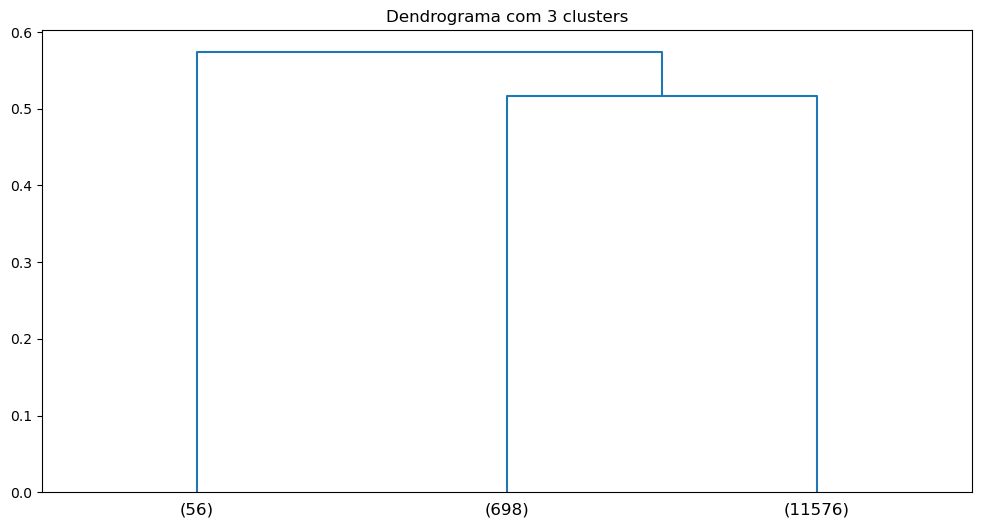

In [21]:
k = 3  # Define o número de clusters desejados

# Obtém os rótulos dos clusters para cada observação usando a matriz de ligação Z
labels_3 = fcluster(Z, k, criterion='maxclust')

# Plota o dendrograma truncado para mostrar apenas os últimos k clusters
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='lastp',  # Mostra apenas os últimos k merges
    p=k,                    # Número de clusters a mostrar
    show_leaf_counts=True,  # Mostra a contagem de folhas em cada cluster
    color_threshold=None,   # Não define limite de cor, todas as ligações têm a mesma cor
    ax=ax
)

plt.title(f"Dendrograma com {k} clusters")
plt.show()

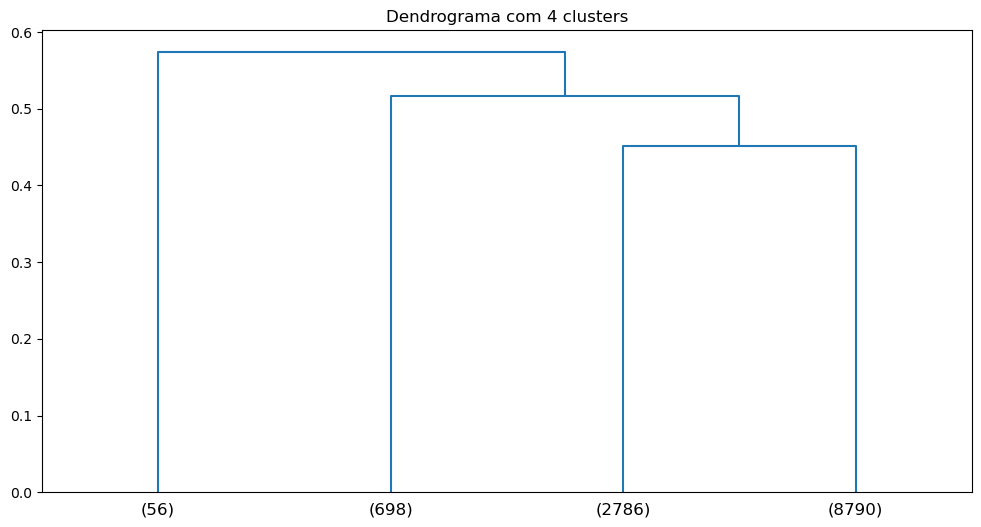

In [22]:
k = 4  # Define o número de clusters desejados

# Obtém os rótulos dos clusters para cada observação usando a matriz de ligação Z
labels_4 = fcluster(Z, k, criterion='maxclust')

# Plota o dendrograma truncado para mostrar apenas os últimos k clusters
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='lastp',  # Mostra apenas os últimos k merges
    p=k,                    # Número de clusters a mostrar
    show_leaf_counts=True,  # Mostra a contagem de folhas em cada cluster
    color_threshold=None,   # Não define limite de cor, todas as ligações têm a mesma cor
    ax=ax
)

plt.title(f"Dendrograma com {k} clusters")
plt.show()

In [23]:
# Calcula o limiar (threshold) de distância para cortar o dendrograma em k clusters.
# O valor é obtido na linha -(k-1) da matriz de ligação Z, coluna 2 (distância do merge).
threshold = Z[-(k-1), 2]
threshold  # Exibe o valor do threshold calculado

0.4517809748649597

Leaves = 12309


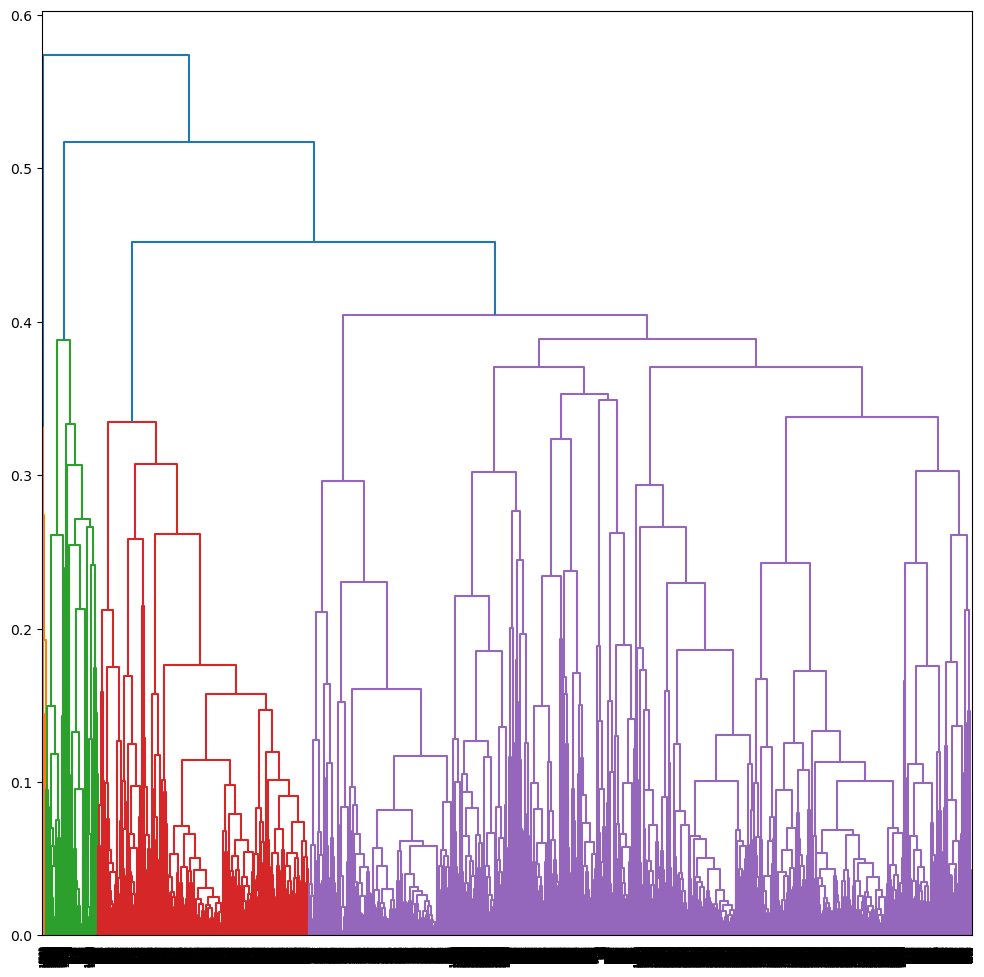

In [24]:
# Cria uma figura e um eixo para o gráfico, com tamanho 12x12
fig, axs = plt.subplots(1, 1, figsize=(12, 12))

# Plota o dendrograma do agrupamento hierárquico, truncando para mostrar apenas os 30 primeiros níveis
# Mostra a contagem de folhas em cada cluster, usa o eixo axs e aplica o threshold de cor definido
dn = dendrogram(Z, truncate_mode='level', p=30, show_leaf_counts=True, ax=axs, color_threshold=threshold)

# Imprime o número de folhas (observações) exibidas no dendrograma
print(f"Leaves = {len(dn['leaves'])}")

In [25]:
# Calcula o número de cores distintas usadas no dendrograma,
# ou seja, o número de grupos/clusters representados visualmente.
print(f"Número de cores = {len(set(dn['color_list']))}")
print(f"Número de clusters = {len(set(labels_4))}")

Número de cores = 5
Número de clusters = 4


## Avaliação dos grupos

Construa os agrupamentos com a técnica adequada que vimos em aula. Não se esqueça de tratar variáveis qualitativas, padronizar escalas das quantitativas, tratar valores faltantes e utilizar a distância correta.

Faça uma análise descritiva para pelo menos duas soluções de agrupamentos (duas quantidades diferentes de grupos) sugeridas no item anterior, utilizando as variáveis que estão no escopo do agrupamento.
- Com base nesta análise e nas análises anteriores, decida pelo agrupamento final. 
- Se puder, sugira nomes para os grupos.

In [26]:
df2 = df_variaveis_selecionadas.copy()  # Cria uma cópia do DataFrame original para análise de clusters

df2['Grupo_3'] = labels_3  # Adiciona a coluna de rótulos do cluster 3 ao DataFrame
df2['Grupo_4'] = labels_4  # Adiciona a coluna de rótulos do cluster 4 ao DataFrame

df2.head()

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,TrafficType,VisitorType,Weekend,Revenue,Grupo_3,Grupo_4
0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,Returning_Visitor,False,False,2,2
1,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,Returning_Visitor,False,False,3,4
2,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,3,Returning_Visitor,False,False,2,2
3,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,4,Returning_Visitor,False,False,2,2
4,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,4,Returning_Visitor,True,False,3,4


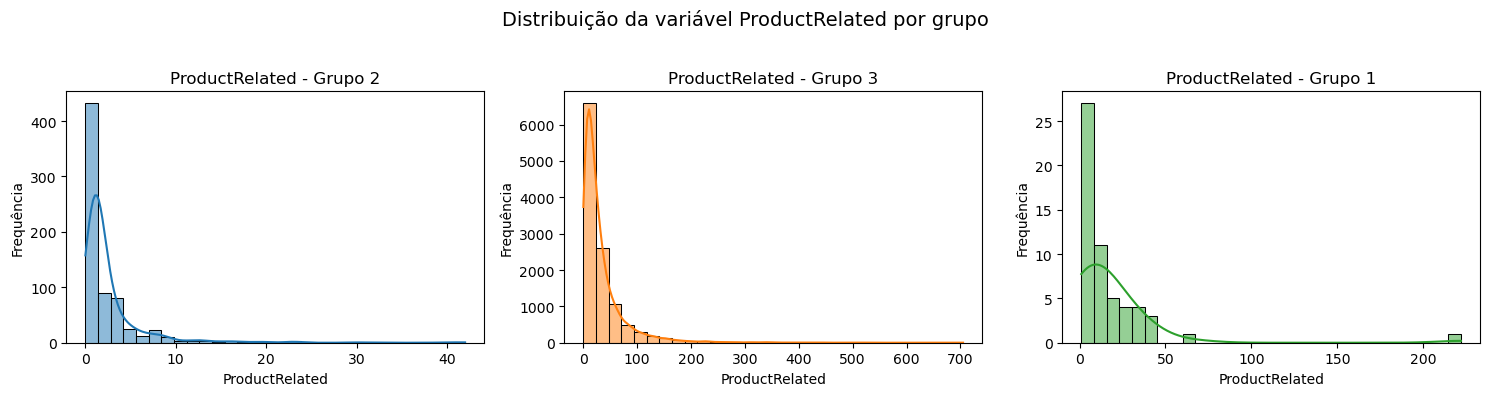

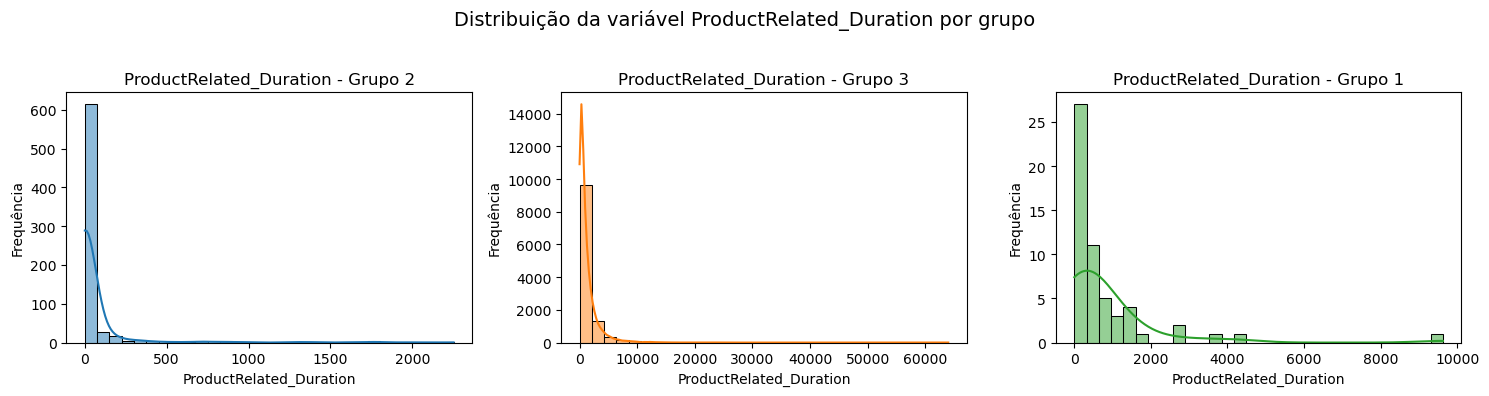

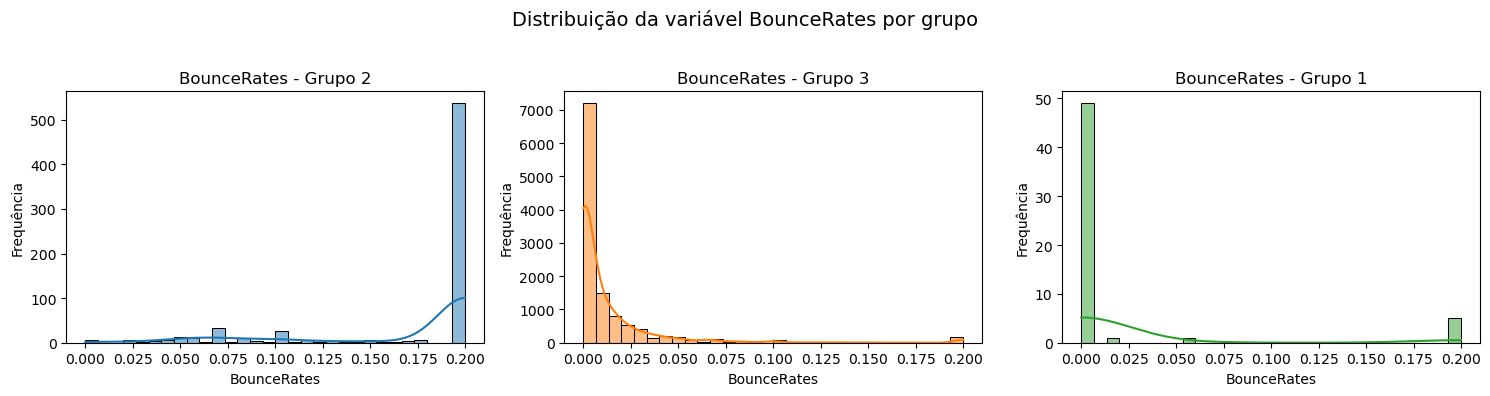

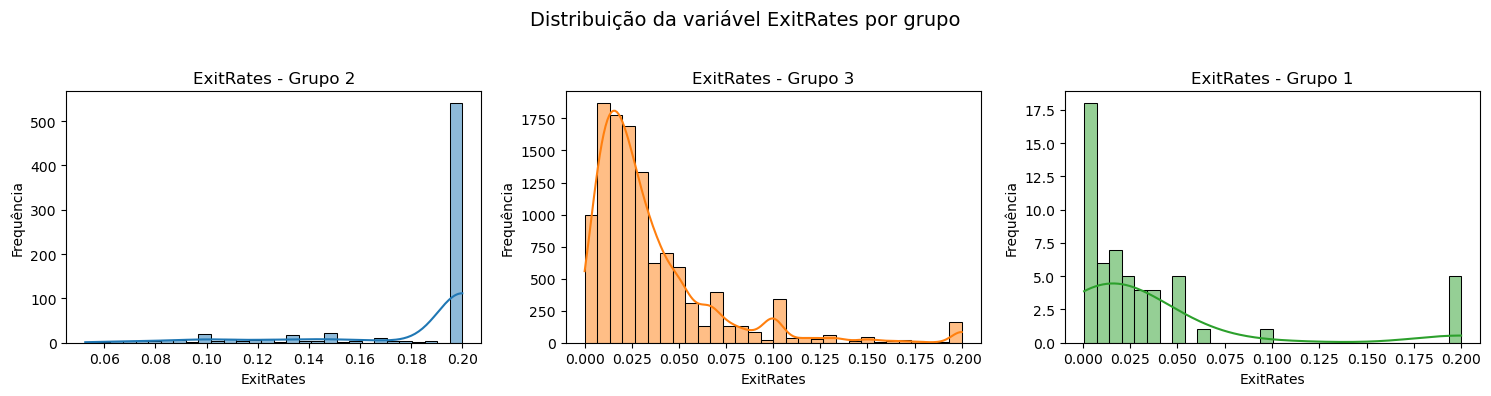

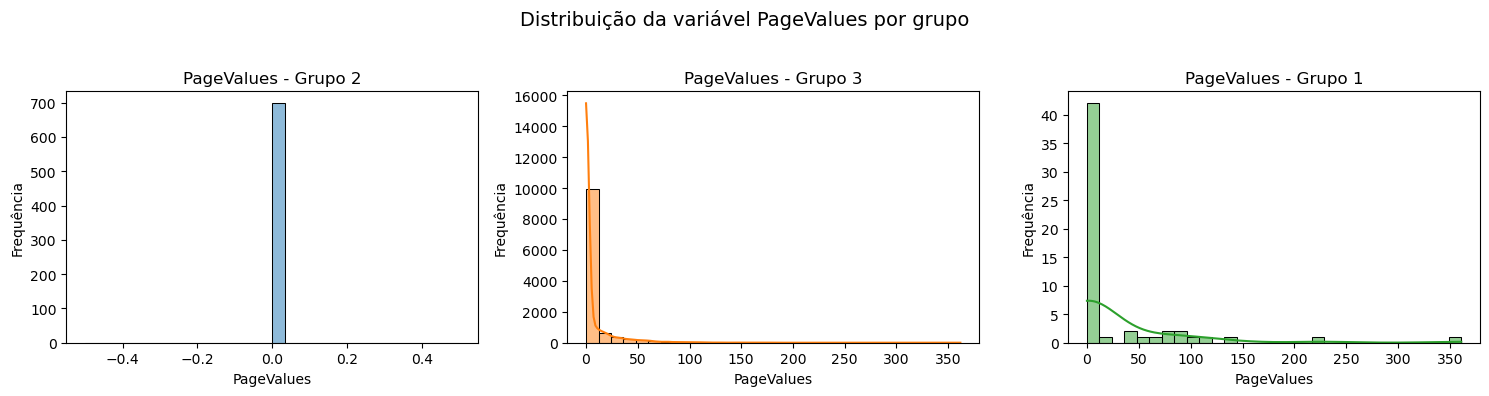

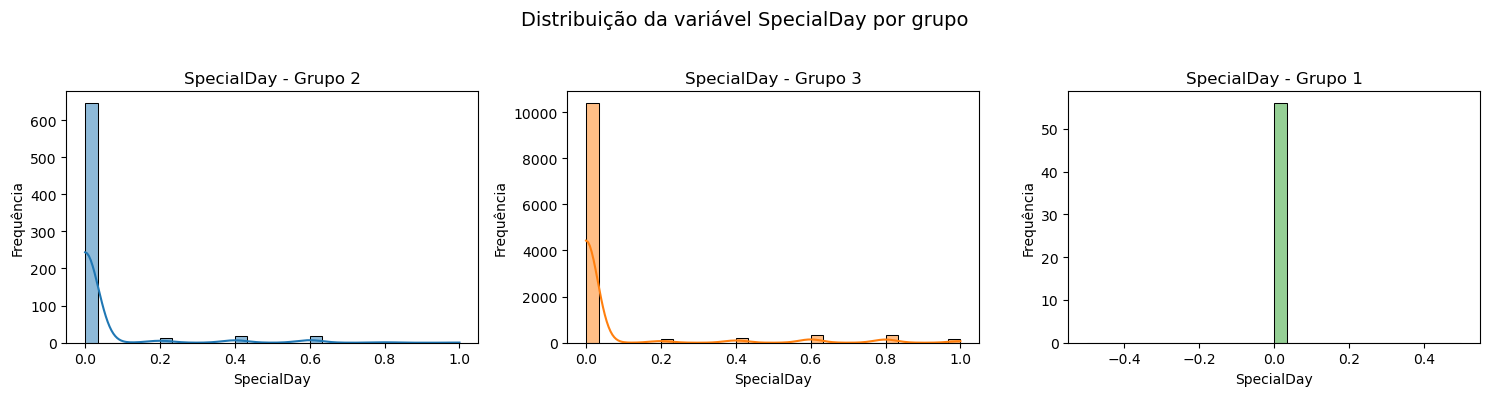

In [27]:
grupos = df2['Grupo_3'].unique()  # Descobre os grupos únicos

for var in variaveis_numericas:
    fig, axs = plt.subplots(1, len(grupos), figsize=(5 * len(grupos), 4))
    
    if len(grupos) == 1:
        axs = [axs]  # Garante que axs seja iterável mesmo com 1 grupo
    
    for i, grupo in enumerate(grupos):
        sns.histplot(
            data=df2[df2['Grupo_3'] == grupo],
            x=var,
            kde=True,
            bins=30,
            ax=axs[i],
            color=sns.color_palette("tab10")[i]
        )
        axs[i].set_title(f'{var} - Grupo {grupo}')
        axs[i].set_xlabel(var)
        axs[i].set_ylabel('Frequência')

    plt.suptitle(f'Distribuição da variável {var} por grupo', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Espaço para o título geral
    plt.show()


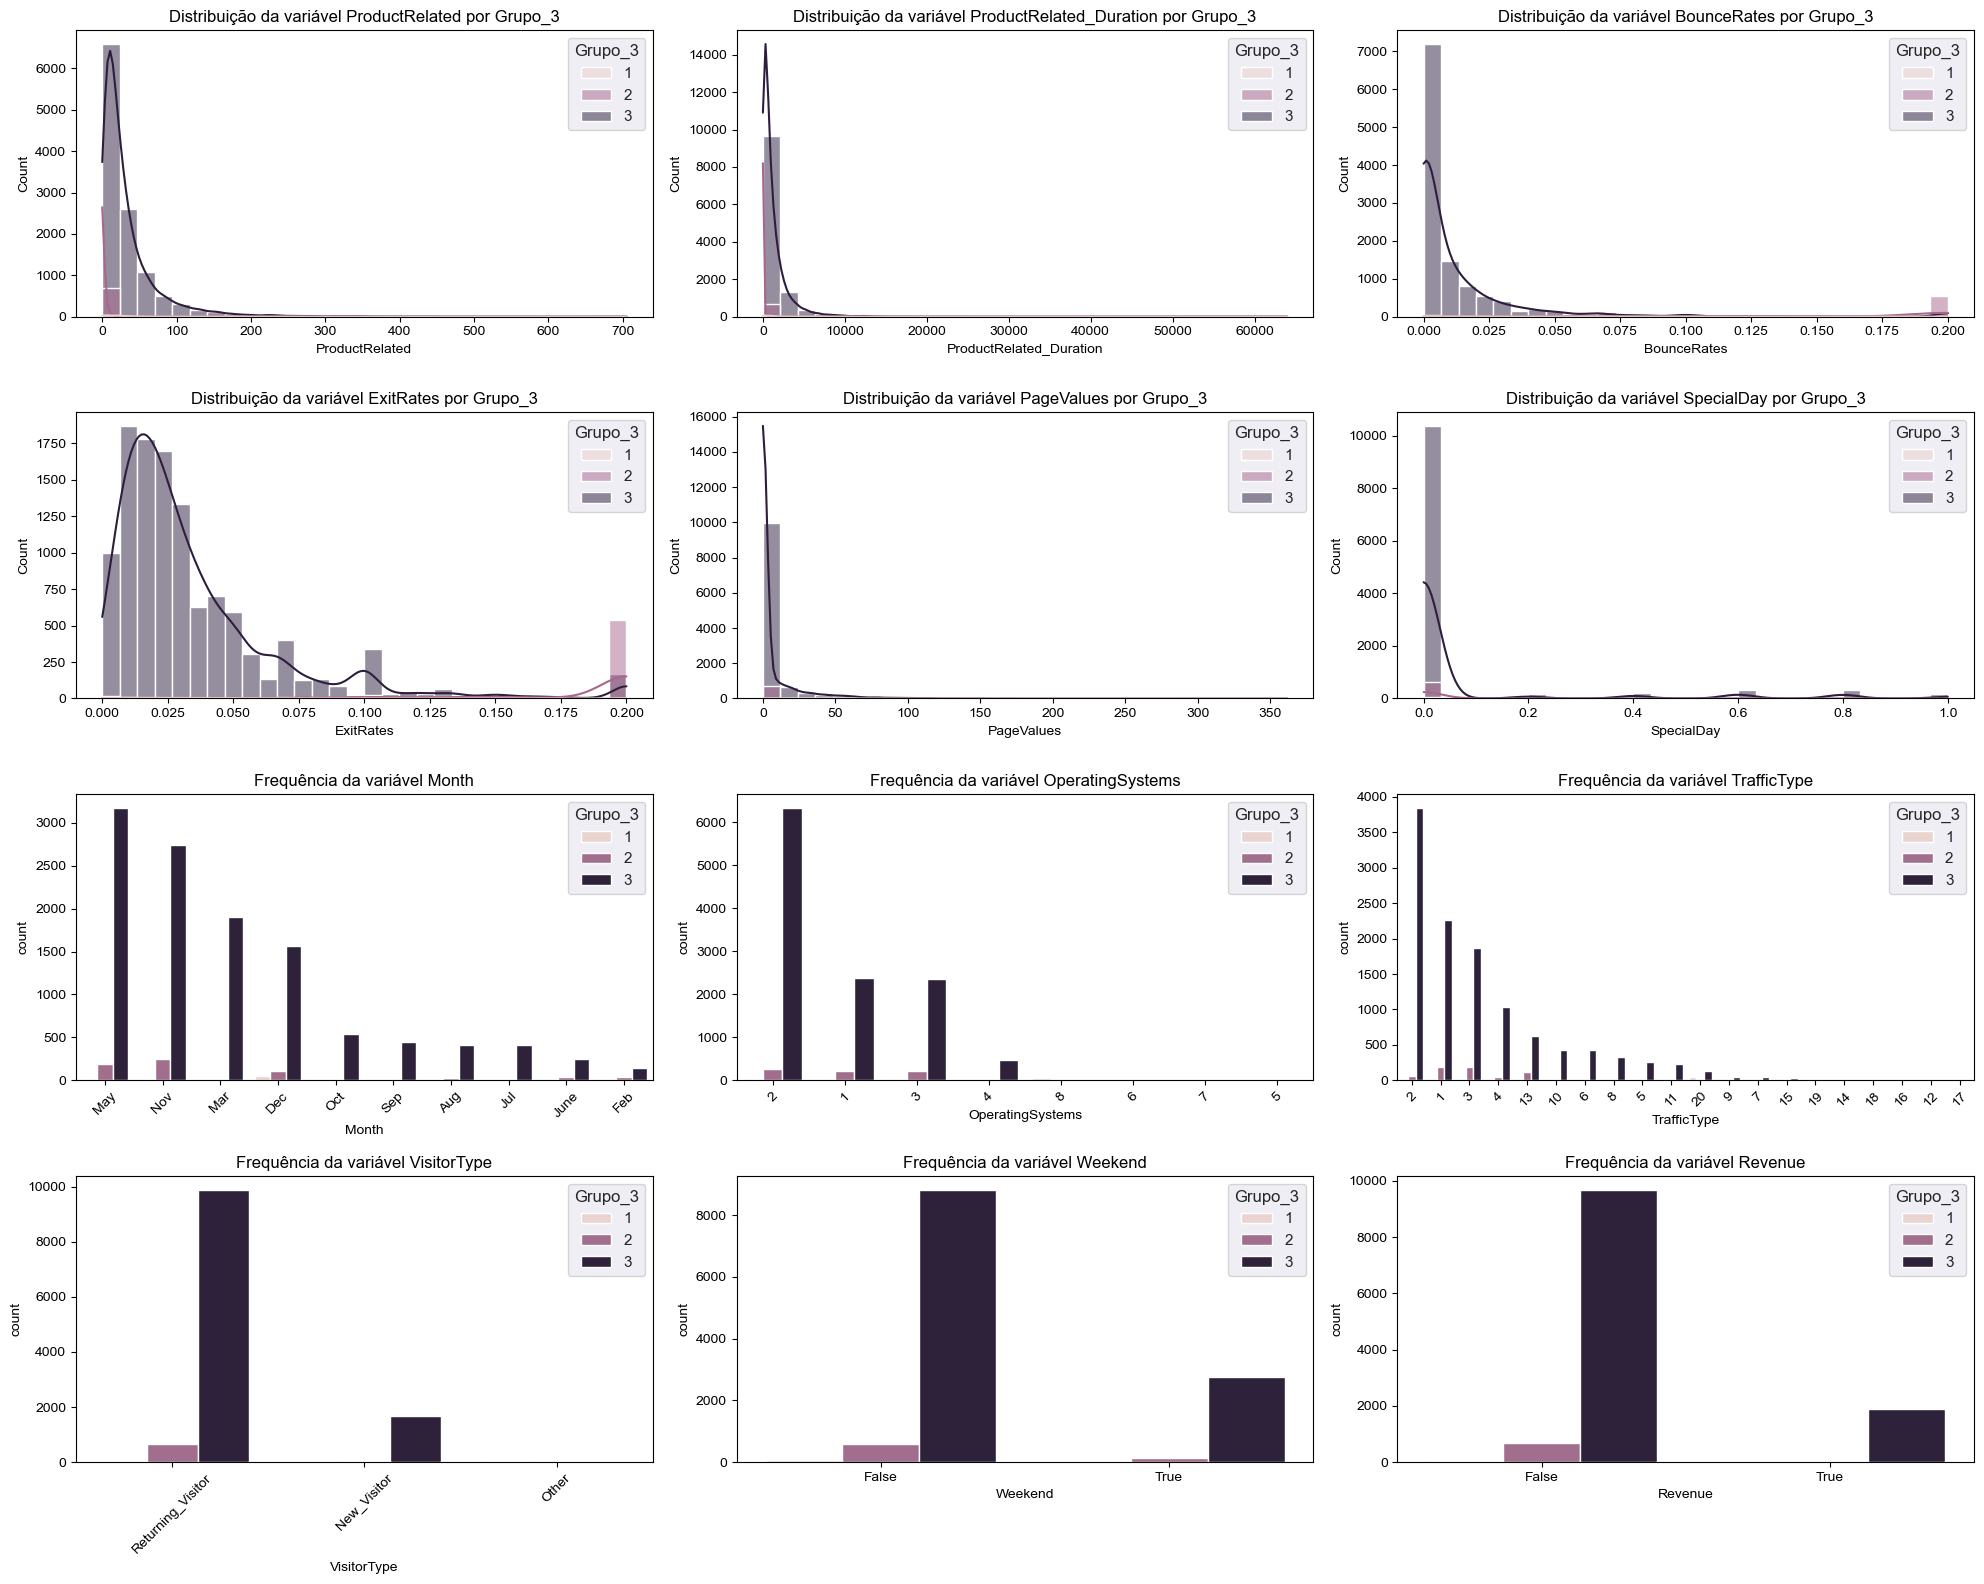

In [28]:
fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(20, 16))
axs = axs.flatten()  # Achata a matriz de eixos para facilitar o acesso
  # Define a paleta de cores para os gráficos
  
sns.set_theme(style='darkgrid', palette='rocket')  # Define o estilo dos gráficos

for i, var in enumerate(variaveis_numericas):
    sns.histplot(data=df2, x=var, hue='Grupo_3', kde=True, bins=30, ax=axs[i])  # Plota histograma com densidade
    axs[i].set_title(f'Distribuição da variável {var} por Grupo_3')  # Título do gráfico
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição

# Para cada variável categórica, plota um gráfico de barras com a frequência de cada categoria
for i, var in enumerate(variaveis_categoricas):
    sns.countplot(data=df2, x=var, hue='Grupo_3', order=df2[var].value_counts().index, ax=axs[i + len(variaveis_numericas)])  # Plota a contagem das categorias em ordem decrescente de frequência
    axs[i + len(variaveis_numericas)].set_title(f'Frequência da variável {var}')  # Adiciona um título ao gráfico
    axs[i + len(variaveis_numericas)].tick_params(axis='x', rotation=45)  # Rotaciona os rótulos do eixo x para melhor visualização
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição
  # Ajusta o layout para evitar sobreposição

# Para cada variável booleana, plota um gráfico de barras com a frequência de cada categoria (True/False)
for i, var in enumerate(variaveis_booleanas):
    sns.countplot(data=df2, x=var, hue='Grupo_3', ax=axs[i + len(variaveis_numericas) + len(variaveis_categoricas)])  # Plota a contagem das categorias (True/False)
    axs[i + len(variaveis_numericas) + len(variaveis_categoricas)].set_title(f'Frequência da variável {var}')  # Adiciona um título ao gráfico
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição

In [29]:
len(variaveis_booleanas) + len(variaveis_categoricas) + len(variaveis_numericas)  # Conta o total de variáveis analisadas

12

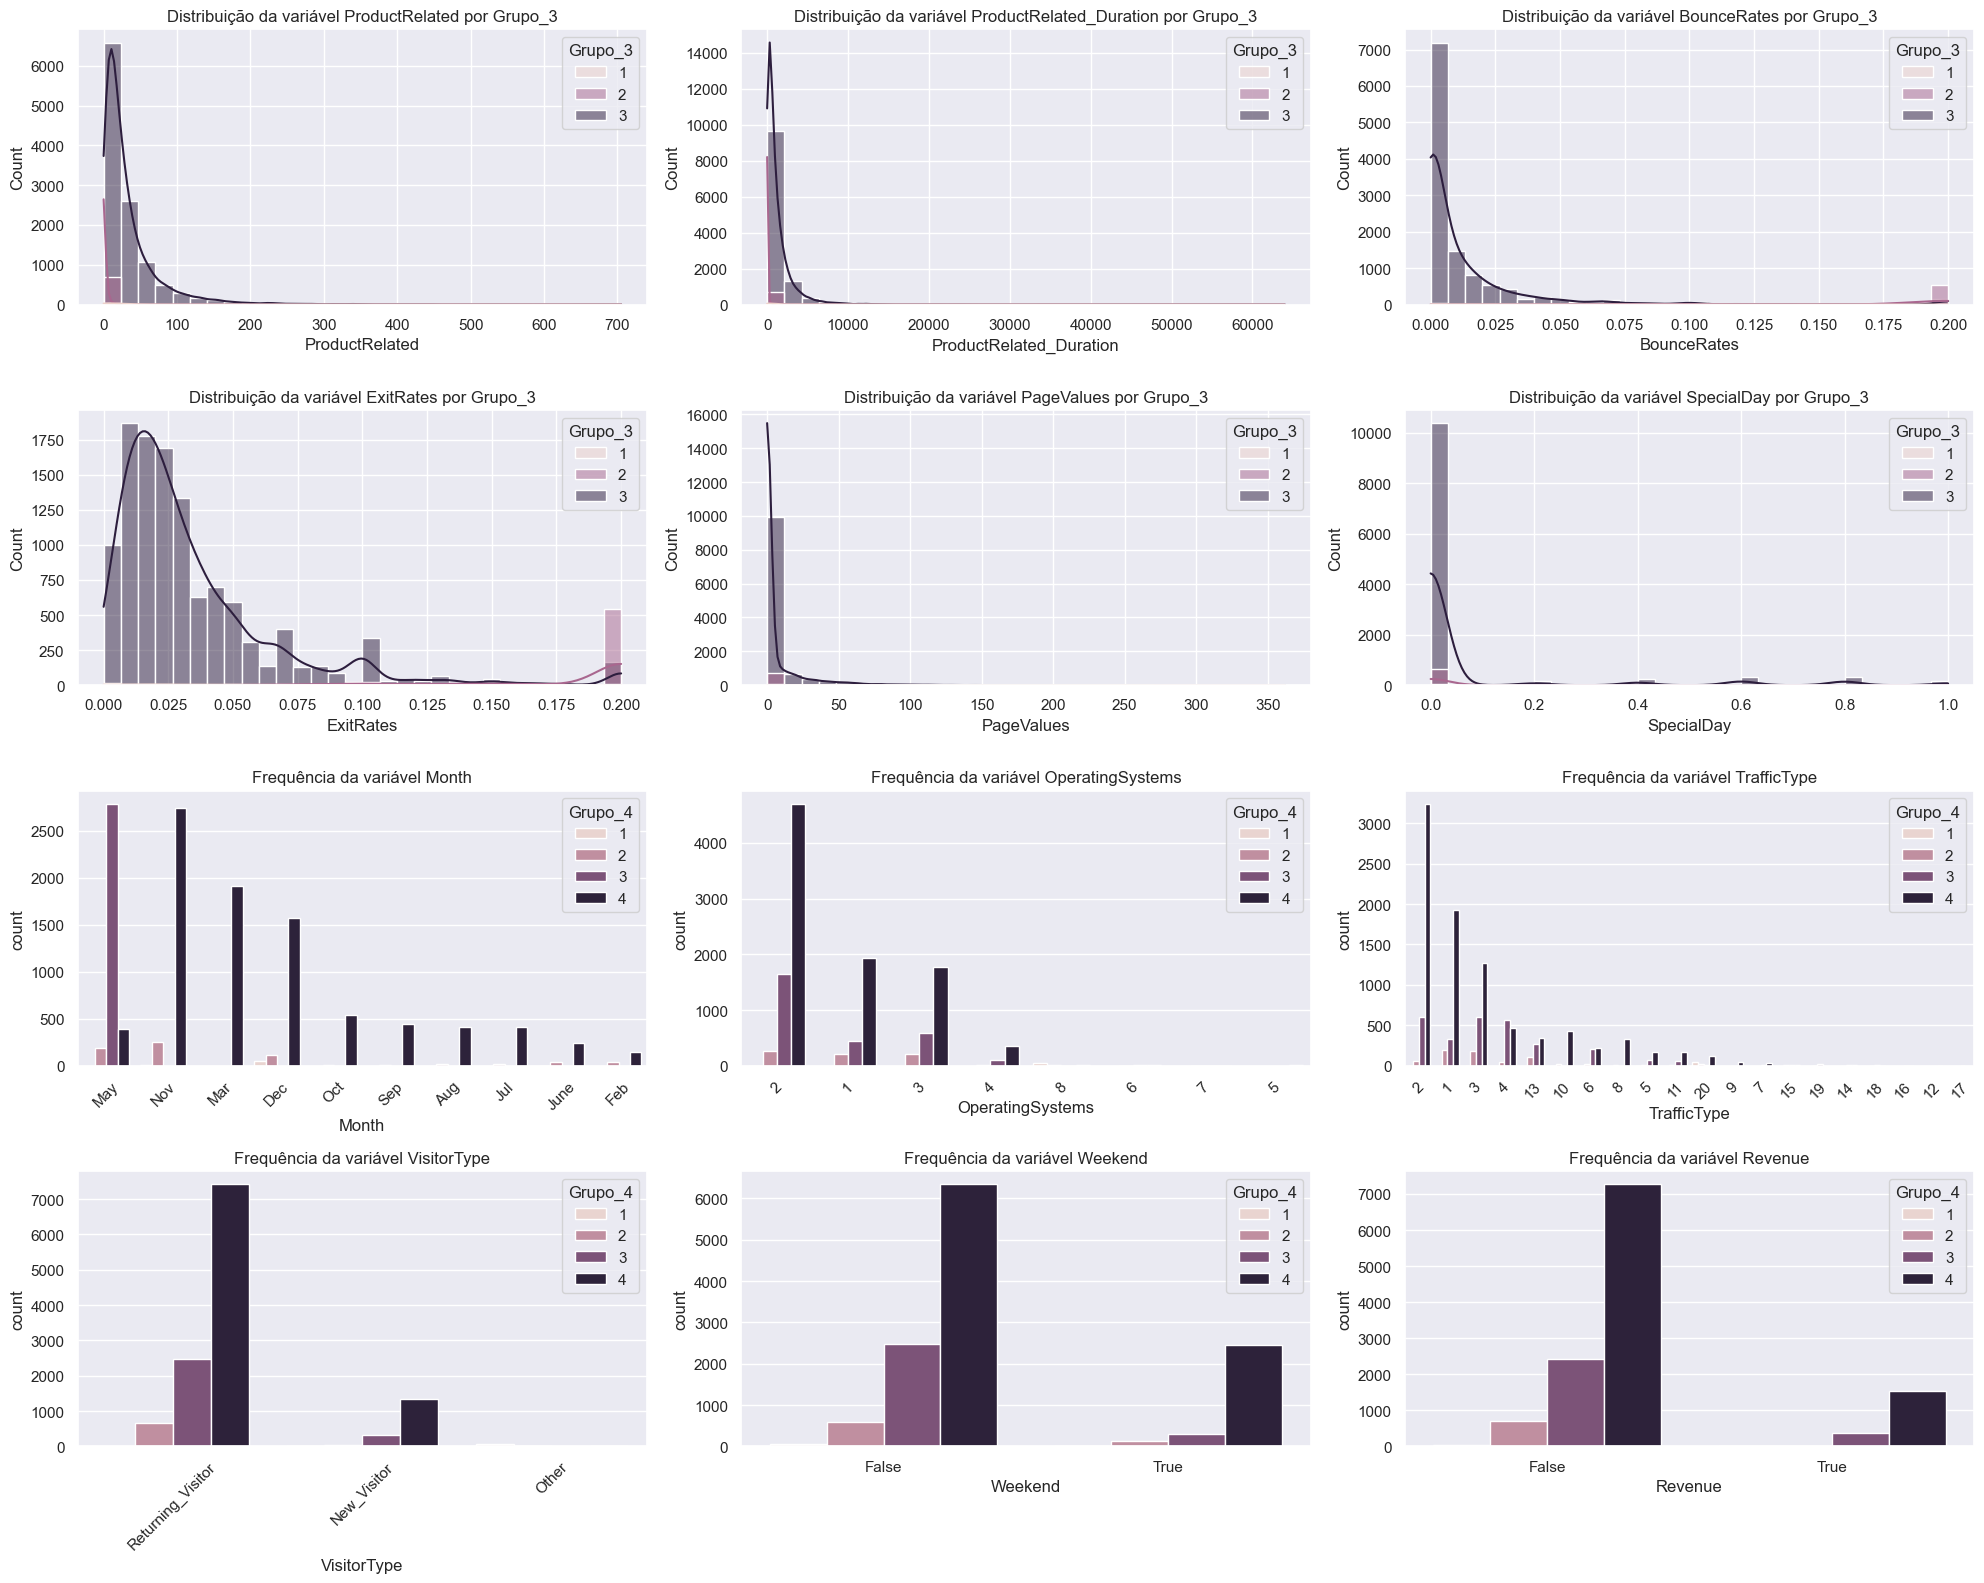

In [30]:
fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(20, 16))
axs = axs.flatten()  # Achata a matriz de eixos para facilitar o acesso
  # Define a paleta de cores para os gráficos
  
sns.set_theme(style='darkgrid', palette='rocket')  # Define o estilo dos gráficos

for i, var in enumerate(variaveis_numericas):
    sns.histplot(data=df2, x=var, hue='Grupo_3', kde=True, bins=30, ax=axs[i])  # Plota histograma com densidade
    axs[i].set_title(f'Distribuição da variável {var} por Grupo_3')  # Título do gráfico
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição


# Para cada variável categórica, plota um gráfico de barras com a frequência de cada categoria
for i, var in enumerate(variaveis_categoricas):
    sns.countplot(data=df2, x=var, hue='Grupo_4', order=df2[var].value_counts().index, ax=axs[i + len(variaveis_numericas)])  # Plota a contagem das categorias em ordem decrescente de frequência
    axs[i + len(variaveis_numericas)].set_title(f'Frequência da variável {var}')  # Adiciona um título ao gráfico
    axs[i + len(variaveis_numericas)].tick_params(axis='x', rotation=45)  # Rotaciona os rótulos do eixo x para melhor visualização
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição
  # Ajusta o layout para evitar sobreposição

# Para cada variável booleana, plota um gráfico de barras com a frequência de cada categoria (True/False)
for i, var in enumerate(variaveis_booleanas):
    sns.countplot(data=df2, x=var, hue='Grupo_4', ax=axs[i + len(variaveis_numericas) + len(variaveis_categoricas)])  # Plota a contagem das categorias (True/False)
    axs[i + len(variaveis_numericas) + len(variaveis_categoricas)].set_title(f'Frequência da variável {var}')  # Adiciona um título ao gráfico
    plt.tight_layout()  # Ajusta o layout para evitar sobreposição


## Avaliação de resultados

Avalie os grupos obtidos com relação às variáveis fora do escopo da análise (minimamente *bounce rate* e *revenue*). 
- Qual grupo possui clientes mais propensos à compra?

**Resposta:**

Ao aplicar o agrupamento com 4 clusters, observa-se que o Grupo 4 apresenta a maior propensão à conversão (compra), sendo o mais relevante nesse aspecto, ainda que compartilhe esse comportamento, em menor grau, com o Grupo 3.

Já no modelo com 3 clusters, somente o Grupo 3 apresenta registros com conversão, enquanto os Grupos 1 e 2 não demonstram nenhuma ocorrência de faturamento.

Considerando que o objetivo do agrupamento é maximizar a distinção entre os grupos com base em seus padrões de comportamento, e que a variável Revenue representa a métrica mais crítica para a finalidade de negócios (compra versus não compra), o modelo com 3 clusters foi mais eficaz em segmentar os usuários com base em propensão à conversão.

Observando a variável BounceRates no agrupamento com 3 clusters, nota-se que o Grupo 2 apresenta um pico acentuado em torno da taxa de 20%, indicando que uma grande parte dos usuários desse grupo abandonam o site rapidamente logo após o acesso.

Em contraste, os Grupos 1 e 3 apresentam distribuições mais diluídas. Embora o Grupo 1 também mostre uma concentração perceptível em torno de 20%, essa frequência não se destaca tanto quanto no Grupo 2 e não constitui o ponto mais alto do histograma.